In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

In [54]:
df = pd.read_csv("../cwt_data/cwt_supervised.csv")

In [55]:
df.head()

,NUM_PKTS_UP_TO_128_BYTES,NUM_PKTS_128_TO_256_BYTES,NUM_PKTS_256_TO_512_BYTES,NUM_PKTS_512_TO_1024_BYTES,NUM_PKTS_1024_TO_1514_BYTES,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,...,pkt_phase,src_mean,src_phase,dst_mean,dst_phase,byte_mean,byte_phase,thr_mean,thr_phase,Label
0,4,0,0,0,0,0,0,0,0,0,...,0.233364,0.000000,3.141593,0.000000,3.141593,15.100750,-0.956510,60402.998858,-0.956510,0
1,87,0,0,0,0,0,14,196,33,0,...,0.233364,17.581824,0.051762,25.194885,0.049700,238.311096,-1.028469,3258.921129,-1.028469,0
2,4,0,0,0,0,0,0,0,0,0,...,0.233364,0.000000,3.141593,0.000000,3.141593,13.727221,-0.979326,54908.885109,-0.979326,0
3,20,0,6,0,6,0,88,999,264,0,...,-0.027926,85.793764,0.017670,87.906681,0.021966,974.560326,-1.251845,6767.786108,-1.251847,0
4,6,2,0,0,0,0,6,19,8,0,...,0.075951,1.311885,0.052357,1.591377,0.038745,48.699588,-0.204543,10529.588968,-0.204542,0


In [56]:
df['Label'].value_counts()

Label
1    33424
0    30000
Name: count, dtype: int64

In [57]:
df_features = df.drop(columns=["Attack"])

In [58]:
df_features.shape

(63424, 28)

In [59]:
df_features.columns

Index(['NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES',
       'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES',
       'NUM_PKTS_1024_TO_1514_BYTES', 'SRC_TO_DST_IAT_MIN',
       'SRC_TO_DST_IAT_AVG', 'SRC_TO_DST_IAT_MAX', 'SRC_TO_DST_IAT_STDDEV',
       'DST_TO_SRC_IAT_MIN', 'DST_TO_SRC_IAT_AVG', 'DST_TO_SRC_IAT_MAX',
       'DST_TO_SRC_IAT_STDDEV', 'IN_BYTES', 'OUT_BYTES',
       'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT', 'pkt_mean',
       'pkt_phase', 'src_mean', 'src_phase', 'dst_mean', 'dst_phase',
       'byte_mean', 'byte_phase', 'thr_mean', 'thr_phase', 'Label'],
      dtype='object')

In [60]:
X = df_features.drop(columns=['Label'])

In [61]:
y = df_features['Label']

In [62]:
print(X.shape)
print(y.shape)

(63424, 27)
(63424,)


In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [64]:
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (50739, 27)
Test size: (12685, 27)


## K-NN

In [74]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [75]:
print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      5953
           1       0.97      0.98      0.97      6732

    accuracy                           0.97     12685
   macro avg       0.97      0.97      0.97     12685
weighted avg       0.97      0.97      0.97     12685



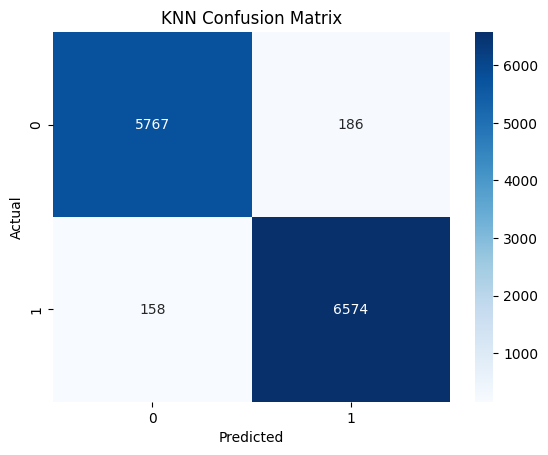

In [76]:
cm = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()